# First Trial with QMOF Data

Distribution of output variables

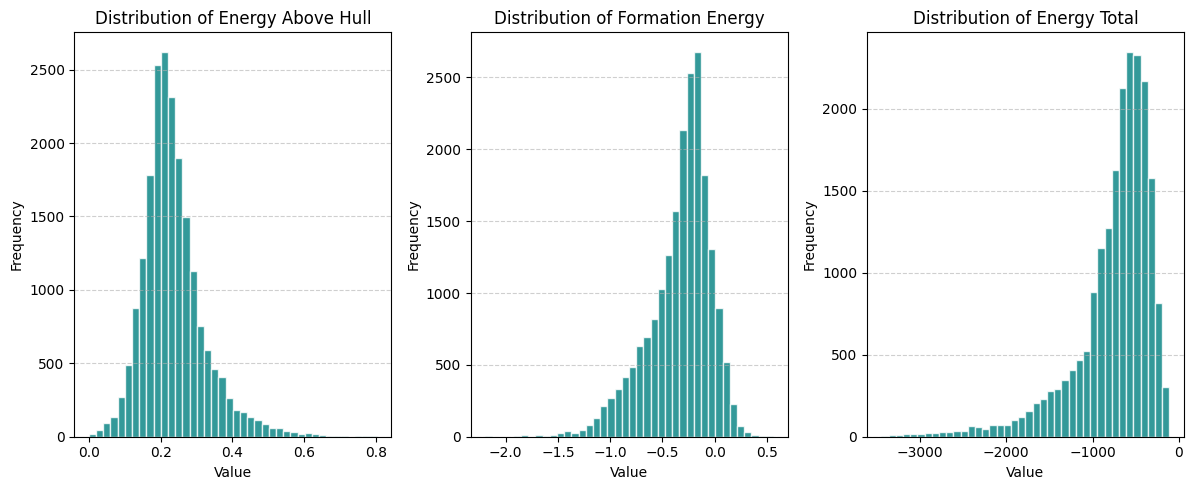

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
file_thermo = "D:\pykan\github\workflows\Hyein\data\qmof\qmof_thermo_database\qmof_thermo_database\qmof_thermo.json"

# Load the JSON directly into a table
df = pd.read_json(file_thermo)

# 2. Define the columns you want to visualize
# Add or remove names based on your specific JSON keys
target_columns = [
    'energy_above_hull',
    'formation_energy',
    'energy_total'
]
target_pretty_names = [
    'Ehull', 'Eform', 'Etotal'
]
# 3. Setup the Grid (e.g., 2 rows, 2 columns)
num_cols = len(target_columns)
cols_per_row = 4
rows = (num_cols + 1) // 4

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 5 * rows))
axes = axes.flatten()  # Flattens to 1D so we can loop easily

# 4. The Loop
for i, col_name in enumerate(target_columns):
    ax = axes[i]

    # Ensure data is numeric/float (handling those Decimal objects)
    data_series = pd.to_numeric(df[col_name], errors='coerce')

    # Draw the histogram
    ax.hist(data_series.dropna(), bins=40, color='teal', edgecolor='white', alpha=0.8)

    # Styling
    ax.set_title(f'Distribution of {col_name.replace("_", " ").title()}', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Clean up extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


Thumbnail for the data structure

In [ ]:
import ijson

# Path to your downloaded QMOF JSON file
file_structure = "D:\pykan\github\workflows\Hyein\data\qmof\qmof_database\qmof_database\qmof_structure_data.json"
# file_path = "D:\pykan\github\workflows\Hyein\data\qmof\qmof_thermo_database\qmof_thermo_database\qmof_thermo.json"

with open(file_structure, 'rb') as f:
    # 'item' assumes your JSON is a list: [{...}, {...}]
    objects = ijson.items(f, 'item')

    # Get just the first object and stop
    first_entry = next(objects)

    print("--- First Entry Keys ---")
    print(first_entry.keys())

In [9]:
print("--- First Entry 'structure' Data ---")
print(first_entry['structure'])

--- First Entry 'structure' Data ---
{'@module': 'pymatgen.core.structure', '@class': 'Structure', 'charge': 0, 'lattice': {'matrix': [[Decimal('6.577866356'), Decimal('0.001198396'), Decimal('2.218642526')], [Decimal('0.78166899'), Decimal('7.070336339'), Decimal('0.96662035')], [Decimal('0.000658751'), Decimal('0.000799513'), Decimal('8.791651588')]], 'a': Decimal('6.9419523112540436'), 'b': Decimal('7.17878940055673'), 'c': Decimal('8.791651649033692'), 'alpha': Decimal('82.25599709677074'), 'beta': Decimal('71.35701701555689'), 'gamma': Decimal('81.58285544631552'), 'volume': Decimal('408.857471262788')}, 'sites': [{'species': [{'element': 'Ba', 'occu': 1}], 'abc': [Decimal('0.09830491028584015'), Decimal('0.7343525664213004'), Decimal('0.35340986612669667')], 'xyz': [Decimal('1.220889999999993'), Decimal('5.192519999999996'), Decimal('4.034999999999976')], 'label': 'Ba', 'properties': {'pbe_ddec_sum_bond_order': Decimal('1.559709'), 'pbe_ddec_charge': Decimal('1.48179'), 'pbe_cm5_

In [11]:
print("--- First Entry 'structure/sites' Data ---")
print(first_entry['structure']['sites'][:5])

--- First Entry 'structure/sites' Data ---
[{'species': [{'element': 'Ba', 'occu': 1}], 'abc': [Decimal('0.09830491028584015'), Decimal('0.7343525664213004'), Decimal('0.35340986612669667')], 'xyz': [Decimal('1.220889999999993'), Decimal('5.192519999999996'), Decimal('4.034999999999976')], 'label': 'Ba', 'properties': {'pbe_ddec_sum_bond_order': Decimal('1.559709'), 'pbe_ddec_charge': Decimal('1.48179'), 'pbe_cm5_charge': Decimal('0.910193'), 'pbe_bader_charge': Decimal('1.705145'), 'pbe_magmom': Decimal('0.001'), 'pbe_ddec_spin_density': Decimal('0.001119'), 'pbe_bader_spin_density': Decimal('0.001378')}}, {'species': [{'element': 'Ba', 'occu': 1}], 'abc': [Decimal('0.901694538181694'), Decimal('0.265646832757696'), Decimal('0.6465909688039274')], 'xyz': [Decimal('6.139300000000021'), Decimal('1.8798100000000137'), Decimal('7.94191999999998')], 'label': 'Ba', 'properties': {'pbe_ddec_sum_bond_order': Decimal('1.559776'), 'pbe_ddec_charge': Decimal('1.481747'), 'pbe_cm5_charge': Decima

'abc' / 'xyz': position of the atom in different coordinates

'properties'
pbe: the calculation method used in DFT
&rarr; so the values are intermediate results computed on the way to get the final output in DFT calculation.

In [ ]:
import pandas as pd
import numpy as np
from decimal import Decimal
import json

with open(file_structure, 'r') as f:
    data_structure = json.load(f)

num_sites = [len(m['structure']['sites']) for m in data_structure]

The 98th percentile of site counts is: 326.0


Text(0, 0.5, 'Frequency')

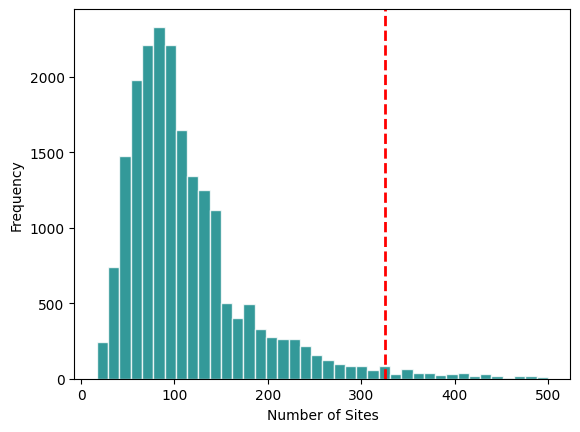

In [7]:
p_criteria = 98
n_max = np.percentile(num_sites, p_criteria)
print(f"The {p_criteria}th percentile of site counts is: {n_max}")

fig = plt.figure()
ax = fig.add_subplot(111)
ax.hist(num_sites, bins=40, color='teal', edgecolor='white', alpha=0.8)

ax.axvline(n_max, color='red', linestyle='--', linewidth=2, label=f'{p_criteria}th Percentile ({int(n_max)})')

ax.set_xlabel('Number of Sites')
ax.set_ylabel('Frequency')

Make a dataset for KAN

In [ ]:
# 2. Identify indices of MOFs that are within the limit
# We do this to ensure df_structure and df (thermo) stay synchronized
valid_indices = [i for i, count in enumerate(num_sites) if count <= n_max]

# 3. Trim the datasets
data_structure_trimmed = [data_structure[i] for i in valid_indices]
df_trimmed = df.iloc[valid_indices].reset_index(drop=True)

print(f"Trimmed {len(data_structure) - len(data_structure_trimmed)} MOFs exceeding n_max.")

# 4. Flatten the trimmed structural data
def flatten_mof(data):
    def to_f(obj):
        return float(obj) if isinstance(obj, Decimal) else obj

    lat = data['lattice']
    row = {
        'lattice_a': to_f(lat['a']),
        'lattice_b': to_f(lat['b']),
        'lattice_c': to_f(lat['c']),
        'lattice_alpha': to_f(lat['alpha']),
        'lattice_beta': to_f(lat['beta']),
        'lattice_gamma': to_f(lat['gamma']),
        'lattice_volume': to_f(lat['volume']),
        'num_sites': len(data['sites'])
    }
    return row

df_structure = pd.DataFrame([flatten_mof(m['structure'] if 'structure' in m else m) for m in data_structure_trimmed])

# 5. Save to CSV following your structure
# Ensure target_columns and target_pretty_names are defined in your environment
for o, name in zip(target_columns, target_pretty_names):
    # Use the trimmed thermo data here
    mof_out = df_trimmed[o]

    # Concatenate the structural features with the specific target property
    df_out = pd.concat([df_structure, mof_out], axis=1)

    output_filename = f"github/workflows/Hyein/data/Mof{name}.csv"

    # Ensure directory exists (optional, but prevents errors)
    # os.makedirs(os.path.dirname(output_filename), exist_ok=True)

    df_out.to_csv(output_filename, index=False)

    print(f"Success! Saved {len(df_out)} MOFs to {output_filename}")